# BBEATSx Phase 3: Decomposition Fidelity & Exogenous Interpretability — DGP 6

This notebook validates BBEATSx on **DGP 6: Linear Trend + Seasonality + Nonlinear Exogenous Covariate + Homoscedastic Noise**.
It measures point/probabilistic forecast calibration and demonstrates covariate interpretability via split importance and Partial Dependence Plots (PDP) under non-linear exogenous effects.

## Google Colab Setup

In [1]:
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Setting up workspace...")
    import os
    if not os.path.abspath(".").endswith("simulations"):
        if not os.path.exists("BBEATSx"):
            !git clone https://github.com/hugogobato/BBEATSx.git
        !pip install ./BBEATSx
        %cd BBEATSx/simulations
    else:
        print("Already in simulations directory.")

import sys
import os
sys.path.append(os.path.abspath("."))
sys.path.append(os.path.abspath(".."))

Running in Google Colab. Setting up workspace...
Cloning into 'BBEATSx'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 59 (delta 14), reused 52 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 61.84 KiB | 2.38 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Processing ./BBEATSx
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for bbeatsx: filename=bbeatsx-0.1.0-py3-none-any.whl size=43805 sha256=e873065d638a2adf2aa81a8bbaaebf098d0fdeda3e66a7212e42d9f81d565f2a
  Stored in directory: /tmp/pip-ephem-wheel-cache-hvpsj_ct/wheels/56/65/89/682968e55e85784c7ae1d0dfd917fdbd4d9c71ec4a8220358b
Successfully built bbeatsx
/content/BBEATSx/simulations


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bbeatsx import BBEATSx, make_config
import utils

## Simulation Configuration

In [3]:
NUM_SIMULATIONS = 100  # Set to 100 for final results on Colab
HORIZON = 20
LEVEL = 0.95
print(f"Running {NUM_SIMULATIONS} trials for DGP 6...")

Running 100 trials for DGP 6...


## Run Simulations

In [4]:
dgp6_forecasts = []
dgp6_components = []

for i in range(NUM_SIMULATIONS):
    t, y, exog, true_comps = utils.generate_dgp6(n=200, seed=i)
    n_train = len(y) - HORIZON
    y_train, y_test = y[:n_train], y[n_train:]

    exog_train = {k: v[:n_train] for k, v in exog.items()}
    exog_test = {k: v[n_train:] for k, v in exog.items()}

    cfg = make_config(
        periods=[(12, 3)],
        lags=(1,),
        exog=["x"],
        trend="spline",
        errors="homo",
        num_gfr=50,
        num_burnin=200,
        num_mcmc=1000,
        seed=i
    )

    model = BBEATSx(cfg).fit(y_train, exog=exog_train)
    fc = model.forecast(HORIZON, exog_future=exog_test)

    dgp6_forecasts.append(utils.evaluate_forecast(y_test, fc, y_train, level=LEVEL))

    s = model.sampler_
    mean, std = s.y_mean_, s.y_std_
    in_sample_draws = s.in_sample_components()
    pred_in_sample = {
        "trend": mean + std * in_sample_draws["trend"],
        "seasonal": std * in_sample_draws["seasonal"],
        "generic": std * in_sample_draws["generic"]
    }
    comp_metrics_in = utils.evaluate_component_fidelity(
        true_comps, pred_in_sample, offset=s.fs.row_offset, level=LEVEL
    )

    pred_out_sample = {
        "trend": fc.components["trend"],
        "seasonal": fc.components["seasonal"],
        "generic": fc.components["generic"]
    }
    true_out_comps = {k: v[n_train:] for k, v in true_comps.items()}
    comp_metrics_out = utils.evaluate_component_fidelity(
        true_out_comps, pred_out_sample, offset=0, level=LEVEL
    )

    dgp6_components.append({
        "in_sample": comp_metrics_in,
        "out_sample": comp_metrics_out
    })

    if (i + 1) % 10 == 0:
        print(f"  Completed trial {i + 1}/{NUM_SIMULATIONS}")

  Completed trial 10/100
  Completed trial 20/100
  Completed trial 30/100
  Completed trial 40/100
  Completed trial 50/100
  Completed trial 60/100
  Completed trial 70/100
  Completed trial 80/100
  Completed trial 90/100
  Completed trial 100/100


## Results Summary

In [5]:
df_fc6 = pd.DataFrame(dgp6_forecasts)
print("\n--- DGP 6 Forecasting Calibration Battery ---")
print(df_fc6.mean().to_frame("Mean Metric"))

comp_in_rmse = {k: np.mean([t["in_sample"][k]["rmse"] for t in dgp6_components]) for k in ["trend", "seasonal", "generic"]}
comp_in_cov = {k: np.mean([t["in_sample"][k]["coverage"] for t in dgp6_components]) for k in ["trend", "seasonal", "generic"]}
comp_out_rmse = {k: np.mean([t["out_sample"][k]["rmse"] for t in dgp6_components]) for k in ["trend", "seasonal", "generic"]}
comp_out_cov = {k: np.mean([t["out_sample"][k]["coverage"] for t in dgp6_components]) for k in ["trend", "seasonal", "generic"]}

df_comp6 = pd.DataFrame({
    "In-Sample RMSE": comp_in_rmse,
    "In-Sample Coverage (95%)": comp_in_cov,
    "Out-of-Sample RMSE": comp_out_rmse,
    "Out-of-Sample Coverage (95%)": comp_out_cov
})
print("\n--- DGP 6 Component Fidelity (Plan §3.2) ---")
print(df_comp6)

# Save evaluation metrics to CSV files
df_fc6.to_csv("dgp6_bbeatsx_forecast_eval.csv", index_label="trial")

comp_rows = []
for idx, c in enumerate(dgp6_components):
    row = {
        "trial": idx
    }
    for sample in ["in_sample", "out_sample"]:
        for comp in ["trend", "seasonal", "generic"]:
            if comp in c[sample]:
                row[f"{sample}_{comp}_rmse"] = c[sample][comp]["rmse"]
                row[f"{sample}_{comp}_coverage"] = c[sample][comp]["coverage"]
    comp_rows.append(row)
df_comp_all = pd.DataFrame(comp_rows)
df_comp_all.to_csv("dgp6_bbeatsx_component_eval.csv", index=False)
print("Saved evaluation metrics to CSV files!")



--- DGP 6 Forecasting Calibration Battery ---
                Mean Metric
rmse               0.687086
smape              7.960307
mase               0.397295
crps               0.413742
pinball            0.216644
coverage           0.966000
interval_score     3.815384

--- DGP 6 Component Fidelity (Plan §3.2) ---
          In-Sample RMSE  In-Sample Coverage (95%)  Out-of-Sample RMSE  \
trend           1.347339                  0.223128            1.163633   
seasonal        0.660600                  0.744078            0.679861   
generic         1.319190                  0.201844            1.239145   

          Out-of-Sample Coverage (95%)  
trend                           0.6800  
seasonal                        0.7950  
generic                         0.3195  
Saved evaluation metrics to CSV files!


## Covariate Interpretability: Variable Importance & Partial Dependence Plot (PDP)

We check the variable split importance in the generic block, and verify if the Partial Dependence Plot successfully recovers the true non-linear relationship ($1.5 \sin(2x) + 0.5 x^2$).


Generic block split importance:
  y_lag1    mean splits= 11.55  P(used)=1.00
  x_x       mean splits= 19.13  P(used)=1.00


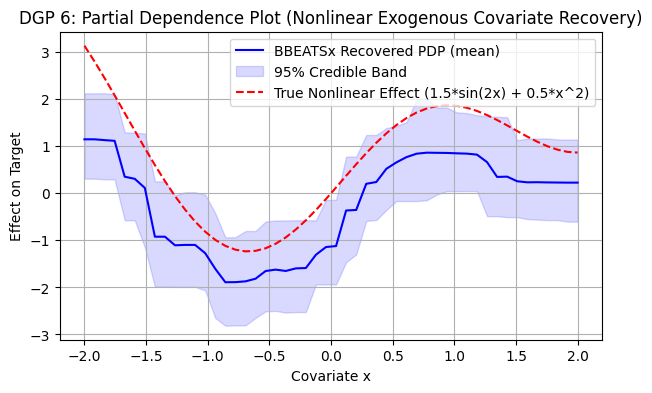

In [7]:
# 1. Split-frequency importance
imp = model.split_importance("generic")
print("\nGeneric block split importance:")
for name, m, p in zip(imp.names, imp.mean, imp.inclusion_prob):
    print(f"  {name:8s}  mean splits={m:6.2f}  P(used)={p:.2f}")

# 2. Partial Dependence Plot for 'x'
names_ge = list(model.sampler_.generic_block.feature_names)
x_idx = names_ge.index("x_x")

grid = np.linspace(-2, 2, 50)
pdp = model.partial_dependence(x_idx, grid, block="generic", level=LEVEL)
true_effect = 1.5 * np.sin(2.0 * grid) + 0.5 * (grid ** 2)

plt.figure(figsize=(7, 4))
plt.plot(pdp.x, pdp.mean, color='blue', label='BBEATSx Recovered PDP (mean)')
plt.fill_between(pdp.x, pdp.lower, pdp.upper, color='blue', alpha=0.15, label='95% Credible Band')
plt.plot(grid, true_effect, color='red', linestyle='--', label='True Nonlinear Effect (1.5*sin(2x) + 0.5*x^2)')
plt.xlabel("Covariate x")
plt.ylabel("Effect on Target")
plt.title("DGP 6: Partial Dependence Plot (Nonlinear Exogenous Covariate Recovery)")
plt.legend()
plt.grid(True)
plt.show()